# Notebook for Generating New Tasks

This notebook contains the analysis presented in the chapter related to generating new tasks, please run the compress .py file to generate the jsonl file used in this.

In [28]:
from transformers import T5ForConditionalGeneration, AutoTokenizer
from alphaarc.task import Task
import torch
import matplotlib.pyplot as plt
import numpy as np 
import json
import torch, tqdm, pickle
from pathlib import Path
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from transformers import T5ForConditionalGeneration, AutoTokenizer
from alphaarc.task import Task, from_dict
import torch
import matplotlib.pyplot as plt
import numpy as np 
import json
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [29]:
# do some loading.

import json
import random
import os



def load_train_tasks(dirs, files, split_keys_path= '../data/split_keys.json', dev_mode=True):
    

    
    tasks = []
    for folder_path in dirs:
         tasks.extend(load_tasks_from_folders(folder_path))
    
    for file_path in files:
        tasks.extend(load_tasks_from_files(file_path))


    

    random.shuffle(tasks)
    return tasks

def load_tasks_from_folders(dir_path):
        tasks = []
        file_paths = [os.path.join(dir_path, f) for f in os.listdir(dir_path)]
        new_tasks = [Task.from_json(path, False) for path in file_paths]
        tasks.extend(new_tasks)

        return tasks

def load_tasks_from_files(file_path):
    tasks = [ ]
    with open(file_path) as fp:
        json_object = json.load(fp)
    task_keys = json_object.keys()
    new_tasks = [from_dict(json_object[key], False) for key in task_keys]
    tasks.extend(new_tasks)

    return tasks

def load_key_split(split_keys_path): 

    with open(split_keys_path) as fp:
        json_object = json.load(fp)

    return json_object


    


tasks = load_train_tasks(dirs=[ '../data/training'],  files=['../data/mutated_tasks_train_9600.json', '../data/mutated_tasks_train_19200.json'])
new_tasks = []
with open("../data/new_tasks.jsonl", "r") as f:
    for line in f:
        new_tasks.append(json.loads(line))


new_tasks = [from_dict(x) for x in new_tasks]


## Number of Duplicate Programs

In [30]:
def compute_n_of_non_duplicate_tasks(new_tasks):
    program_lines = []

    for task in new_tasks:
        program_lines.append( task.program_lines)
    print(f"n of unique programs: {len(set(program_lines))} / {len(program_lines)}")


compute_n_of_non_duplicate_tasks(new_tasks)

n of unique programs: 3634 / 6011


## Number of Tasks Generated Per Task

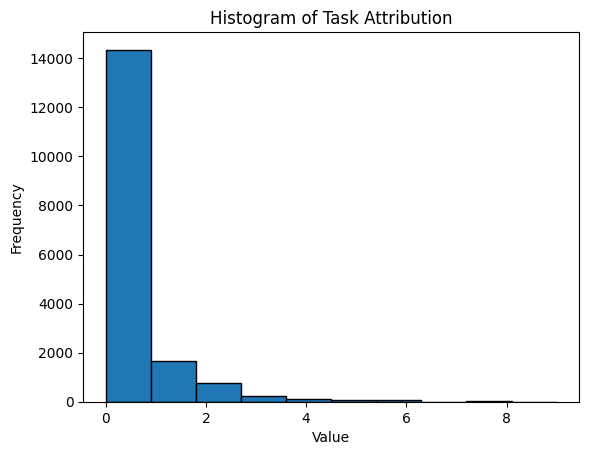

In [31]:
def compute_n_generating_tasks(original_tasks, new_tasks):
    
    save = {}
    for t in original_tasks:
        save[t.task_key] = []




    for t_id in save.keys():

        for new_t in new_tasks:
            if new_t.parent_key == t_id:
                save[t_id].append(new_t) 
    

    data = [len(arr) for arr in save.values()]
    plt.hist(data,edgecolor='black')

    # Add labels and title
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Histogram of Task Attribution')
    # Set more x-axis ticks
    # Show plot
    plt.show()



        


compute_n_generating_tasks(tasks, new_tasks)

## Histogram of Lengths

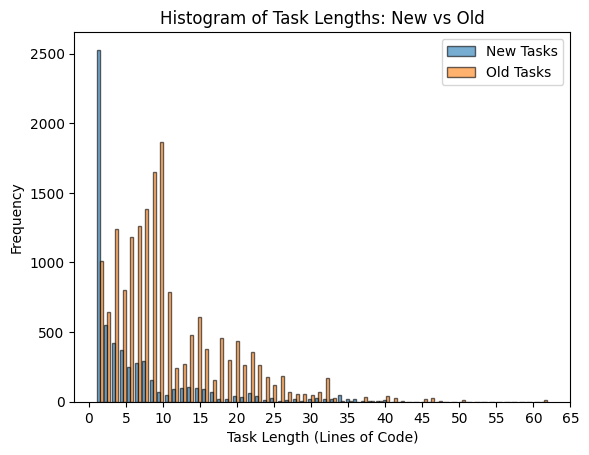

In [32]:
def plot_histogram_of_new_tasks_lengths(new_tasks, old_tasks):
    new_data = [len(task.program_lines.split("\n")) for task in new_tasks]
    old_data = [len(task.program_lines.split("\n")) for task in old_tasks]

    plt.hist([new_data, old_data], bins=60, edgecolor='black', alpha=0.6, label=['New Tasks', 'Old Tasks'])

    # Add labels and title
    plt.xlabel('Task Length (Lines of Code)')
    plt.ylabel('Frequency')
    plt.title('Histogram of Task Lengths: New vs Old')

    # Set x-axis ticks
    min_val = min(min(new_data), min(old_data))
    max_val = max(max(new_data), max(old_data))
    xticks = np.arange(0, max_val + 5, 5)
    plt.xticks(xticks)

    # Add legend
    plt.legend()

    # Show plot
    plt.show()

plot_histogram_of_new_tasks_lengths(new_tasks, tasks)

## Regular Points or Interpoints?

In [33]:
def compute_ratio_of_split_points(tasks, new_tasks):
    save = {}
    for t in tasks:
        save[t.task_key] = []




    for t_id in save.keys():

        for new_t in new_tasks:
            if new_t.parent_key == t_id:
                save[t_id].append(new_t) 
    

    data = [len(arr) for arr in save.values()]

    total_tasks = sum(data)
    print(f"programs created by original tasks {total_tasks} and by intersplit point {len(new_tasks) - total_tasks}")

compute_ratio_of_split_points(tasks, new_tasks)

programs created by original tasks 5064 and by intersplit point 947


## Created by Left or Right?

In [34]:
def compute_left_or_right(tasks, new_tasks):

    left_count = 0
    right_count = 0

    for task in new_tasks:

        if "R" in task.task_key:
            right_count +=1
        else:
            left_count +=1
    

    print(f"created by left: {left_count} created by right: {right_count}")


compute_left_or_right(tasks, new_tasks)


created by left: 3310 created by right: 2701


## Qualative Example

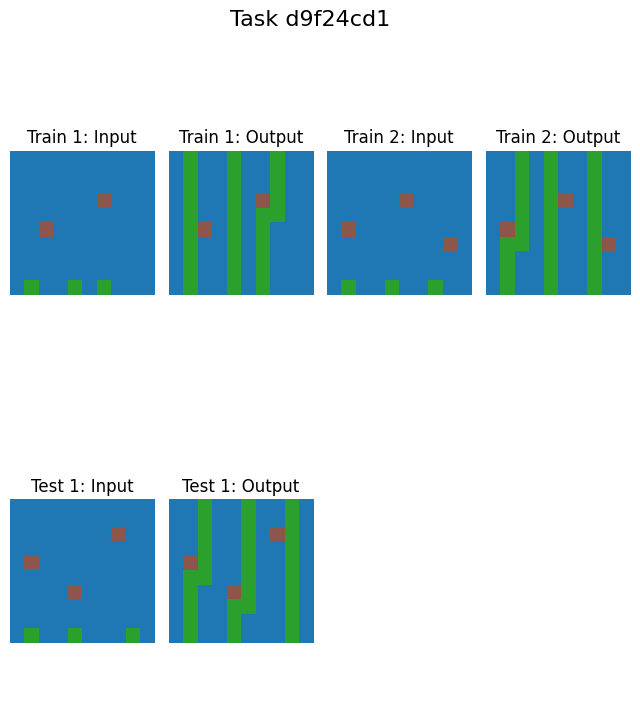

x1 = ofcolor(I, TWO)
x2 = ofcolor(I, FIVE)
x3 = prapply(connect, x1, x2)
x4 = mfilter(x3, vline)
x5 = underfill(I, TWO, x4)
x6 = matcher(numcolors, TWO)
x7 = objects(x5, F, F, T)
x8 = sfilter(x7, x6)
x9 = difference(x7, x8)
x10 = colorfilter(x9, TWO)
x11 = mapply(toindices, x10)
x12 = apply(urcorner, x8)
x13 = shift(x12, UNITY)
x14 = rbind(shoot, UP)
x15 = mapply(x14, x13)
x16 = fill(x5, TWO, x15)
x17 = mapply(vfrontier, x11)
O = fill(x16, TWO, x17)
x1 = ofcolor(I, TWO)
x2 = ofcolor(I, FIVE)
x3 = prapply(connect, x1, x2)
x4 = mfilter(x3, vline)
O = underfill(I, TWO, x4)


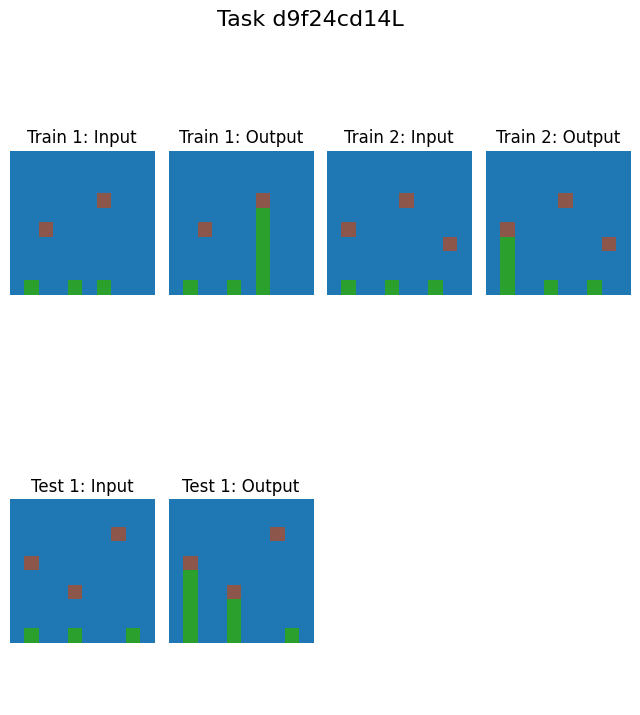

x1 = matcher(numcolors, TWO)
x2 = objects(I, F, F, T)
x3 = sfilter(x2, x1)
x4 = difference(x2, x3)
x5 = colorfilter(x4, TWO)
x6 = mapply(toindices, x5)
x7 = apply(urcorner, x3)
x8 = shift(x7, UNITY)
x9 = rbind(shoot, UP)
x10 = mapply(x9, x8)
x11 = fill(I, TWO, x10)
x12 = mapply(vfrontier, x6)
O = fill(x11, TWO, x12)


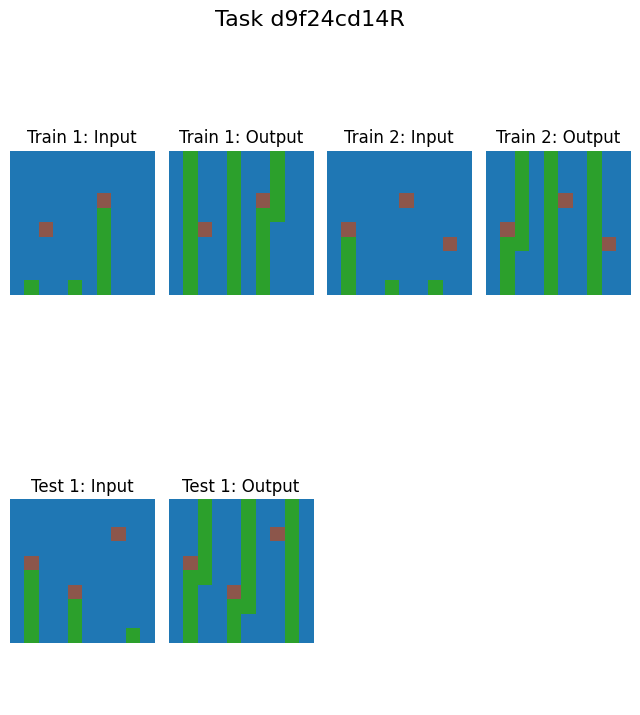

In [ ]:


def display_qualative_example(tasks, new_tasks, chosen_task='d9f24cd1'): 


    chosen_task_obj = None

    for t in tasks:
        if chosen_task  == t.task_key:
            chosen_task_obj = t


    chosen_task_obj.display_task()

    print(chosen_task_obj.program_lines)

    created_tasks = []


    for t in new_tasks:

        if t.parent_key == chosen_task_obj.task_key:
            created_tasks.append(t)


    for x in created_tasks:
        print(x.program_lines)
        x.display_task()


display_qualative_example(tasks, new_tasks)

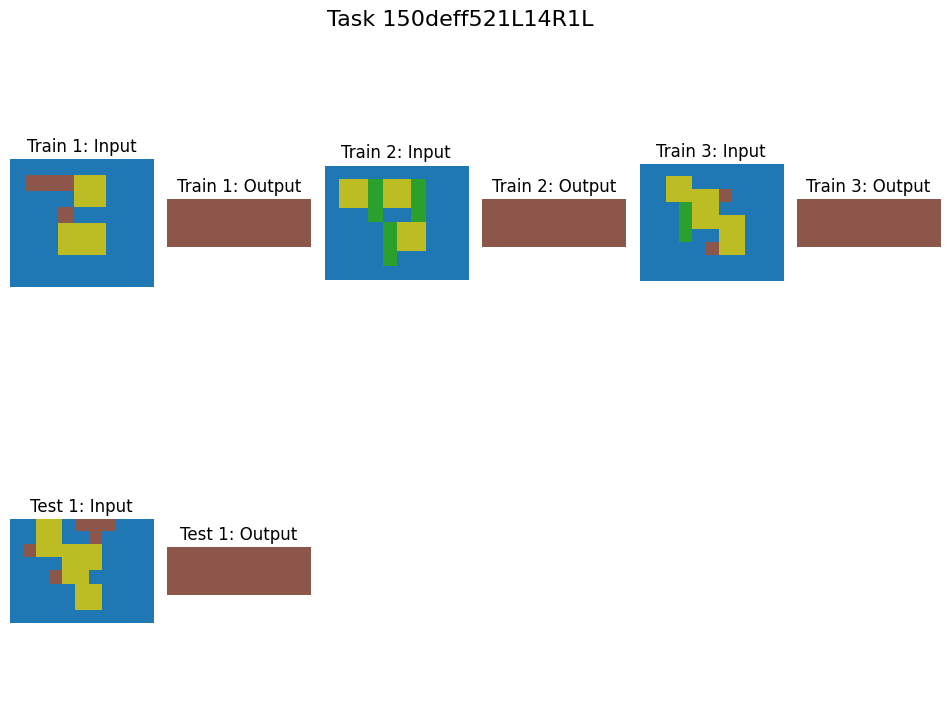

x1 = astuple(ONE, THREE)
O = canvas(FIVE, x1)


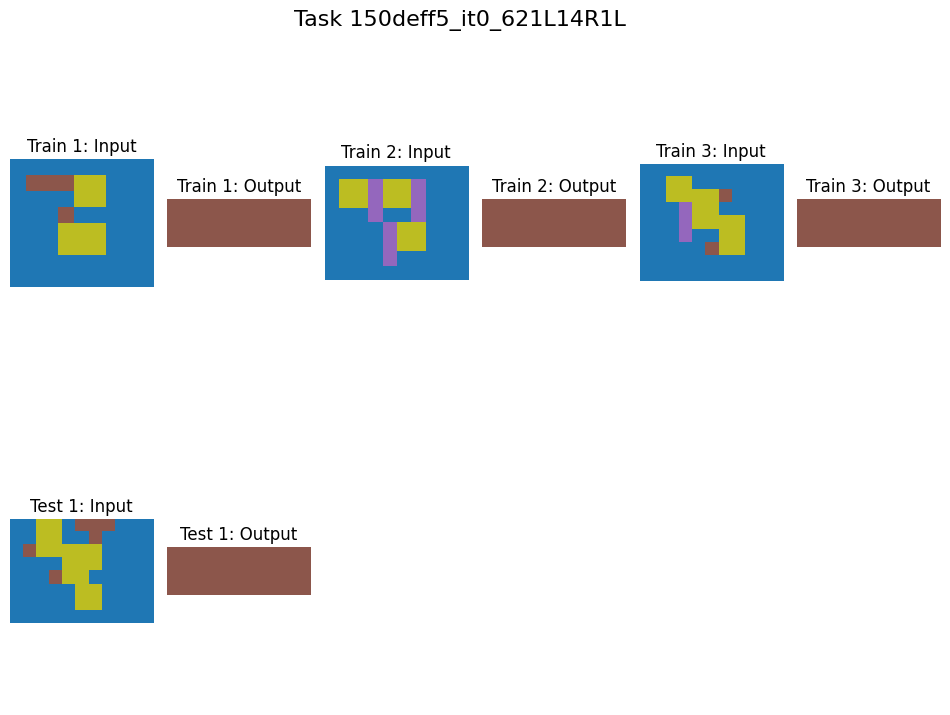

x1 = astuple(ONE, THREE)
O = canvas(FIVE, x1)


In [44]:
from collections import defaultdict

def display_one_duplicate_task_pair(new_tasks):
    program_map = defaultdict(list)

    for task in new_tasks:
        program_map[task.program_lines].append(task)

    for tasks in reversed(program_map.values()):
        if len(tasks) > 1:
            task1, task2 = tasks[0], tasks[1]
         
            return task1, task2

    print("No duplicate task pairs found.")




task1, task2 = display_one_duplicate_task_pair(new_tasks)


task1.display_task()
print(task1.program_lines)
task2.display_task()

print(task2.program_lines)